# Cement-bond evaluation behind casing

*A `sonic_ml` walkthrough of the cased-hole path: a forward **operator** over the
casing/cement annulus, a learned bond inverse, and — the part worth staying for —
an honest account of what is and isn't recoverable.*

The [open-hole tutorial](sonic_ml_tutorial.ipynb) ended with a learned inverse
beating classical slowness-time processing by roughly an order of magnitude. It
would be easy to assume the same trick simply transfers once casing and cement
are added. It does not, and the reason is physics rather than modelling.

This notebook runs the cased-hole loop end to end:

1. **Generate** a cased-hole dataset — casing + cement annulus, graded bond.
2. **Ask the forward model what is even knowable**, before training anything.
3. **Train a forward operator** and evaluate it on a frequency grid it never saw.
4. **Train the bond inverse** and score it against a classical baseline.
5. **Check the uncertainty is calibrated** — the part that makes step 2's answer
   actionable instead of embarrassing.

Everything is synthetic and sized to run in about a minute.

## Setup

As before, `sonic_ml`'s pure-NumPy spine is torch-free; only `sonic_ml.models`
pulls in PyTorch.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import sonic_ml
from sonic_ml import (
    default_geometry,
    gen_shim,
    load_npz,
    stratified_split,
)
from sonic_ml.baselines.bond import StoneleyBondBaseline
from sonic_ml.bench import format_scorecard
from sonic_ml.bench.bond import (
    BOND_ROW_ORDER,
    MeanBondPredictor,
    bond_regime_labels,
    evaluate_bond,
)
from sonic_ml.determinism import seed_everything
from sonic_ml.models.cased import cased_features
from sonic_ml.models.cased_inverse import (
    NeuralBondPredictor,
    cased_residual_zscore_std,
    cased_target_mae,
    train_cased_inverse,
)
from sonic_ml.models.cased_train import (
    resolution_transfer_error,
    slowness_mae_us_per_ft,
    train_cased_operator,
)

seed_everything(0)
workdir = Path(tempfile.mkdtemp(prefix="sonic_ml_cased_"))
print("sonic_ml", sonic_ml.__version__, "| scratch:", workdir)

sonic_ml 0.0.1 | scratch: /tmp/sonic_ml_cased_iamdi0qe


## 1. A cased-hole dataset

Behind casing, the borehole is no longer fluid against formation. It is a
layered stack — fluid → steel casing → cement → formation — and fwap's
cylindrical-Biot solver handles that directly via
`stoneley_dispersion_layered`, so the generator can label cased samples with the
same machinery that produced the open-hole set.

Each sample draws a formation, a steel casing, and a cement sheath, and records
a **bond index** in `[0, 1]`: a normalized cement-quality proxy derived from the
cement shear velocity. That is the quantity a cement evaluation exists to
estimate.

One scope note up front, because it shapes everything below: the dataset spans
the **bonded** regime, where the cased Stoneley mode stays *bound* and the
solver returns a clean dispersion curve. A fully debonded free pipe is a
different (leaky, casing-ring-dominated) problem that this bound-mode dataset
does not contain.

In [2]:
gen = gen_shim.generator()
freq = gen.default_freq_grid(n_freq=48)

N = 200
npz_path = workdir / "cased.npz"
gen.save_npz(str(npz_path), gen.generate_cased_dataset(N, seed=0, freq=freq))

bundle = load_npz(str(npz_path))
geom = default_geometry(bundle)
split = stratified_split(bundle, seed=0)

print(f"samples     {bundle.n_samples}   schema v{bundle.schema_version}  cased={bundle.is_cased}")
print(f"modes       {bundle.mode_names}")
print(f"annulus     {bundle.layer_names}   layer_params {bundle.layer_params.shape}")
print(f"gather      {bundle.gather.shape}")
print(f"bond index  [{bundle.bond_index.min():.2f}, {bundle.bond_index.max():.2f}]")
print(f"split       {split.train.size} train / {split.val.size} val / {split.test.size} test")

labels = bond_regime_labels(bundle)
for code_, name in enumerate(("poor", "medium", "good")):
    print(f"  bond {name:<6} {int((labels == code_).sum()):>4} samples")

samples     200   schema v4  cased=True
modes       ('Stoneley',)
annulus     ('casing', 'cement')   layer_params (200, 2, 4)
gather      (200, 8, 2048)
bond index  [0.01, 1.00]
split       160 train / 20 val / 20 test
  bond poor     70 samples
  bond medium   65 samples
  bond good     65 samples


## 2. Before training anything: what is knowable?

The most useful half-hour in an inverse problem is usually spent on the
*forward* model. Here we hold everything fixed and sweep one parameter at a
time, asking how much each one actually moves the cased Stoneley curve. Whatever
barely moves the data cannot be recovered from it, no matter how good the
network is.

In [3]:
from fwap import BoreholeLayer, stoneley_dispersion_layered

sweep_freq = np.linspace(1000.0, 12000.0, 48)
casing = BoreholeLayer(vp=5860.0, vs=3140.0, rho=7800.0, thickness=0.01)
base = dict(vp=4000.0, vs=2350.0, rho=2400.0, vf=1500.0, rho_f=1000.0, a=0.10)


def cased_curve(cement_vs, thickness=0.045, **overrides):
    params = {**base, **overrides}
    cement = BoreholeLayer(vp=2300.0, vs=float(cement_vs), rho=1900.0, thickness=thickness)
    mode = stoneley_dispersion_layered(sweep_freq, **params, layers=(casing, cement))
    return mode.slowness * 0.3048e6  # us/ft


def spread(a, b):
    return float(np.nanmax(np.abs(a - b)))


sweeps = {
    "cement stiffness (bond)": (cased_curve(1500.0), cased_curve(1950.0)),
    "cement thickness": (cased_curve(1700.0, thickness=0.03), cased_curve(1700.0, thickness=0.06)),
    "formation Vs": (cased_curve(1700.0, vs=1700.0), cased_curve(1700.0, vs=3000.0)),
    "borehole radius": (cased_curve(1700.0, a=0.09), cased_curve(1700.0, a=0.11)),
}

print("Effect on the cased Stoneley curve, sweeping each parameter across its prior:\n")
for name, (lo, hi) in sorted(sweeps.items(), key=lambda kv: -spread(*kv[1])):
    print(f"  {name:<26} {spread(lo, hi):6.2f} us/ft")

Effect on the cased Stoneley curve, sweeping each parameter across its prior:

  cement stiffness (bond)     15.82 us/ft
  cement thickness             4.05 us/ft
  borehole radius              3.34 us/ft
  formation Vs                 3.29 us/ft


That ordering is the whole story of this notebook.

**Cement stiffness — the bond — dominates.** It moves the curve several times
harder than the formation shear velocity does, and the formation's effect is
smaller than the nuisance variation from cement thickness alone.

So before a single epoch of training we can predict the outcome: *bond should be
recoverable; behind-casing Vs should be weak and confounded.* Let's see the
curves.

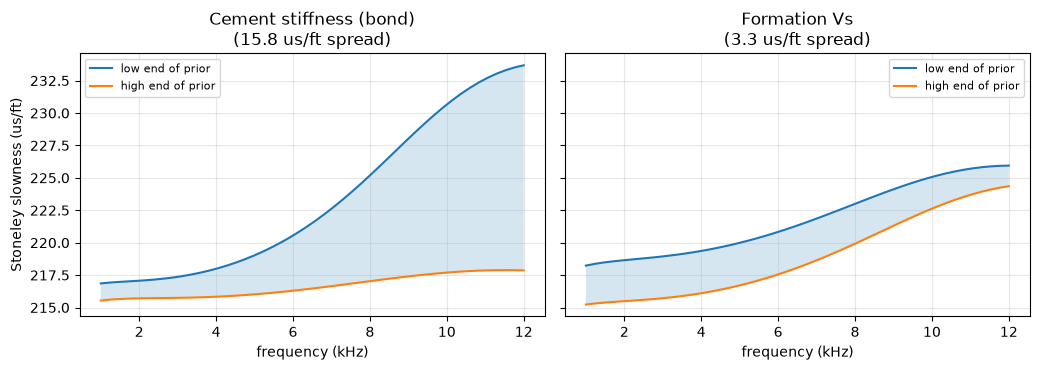

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
for ax, (name, key) in zip(axes, [("Cement stiffness (bond)", "cement stiffness (bond)"),
                                  ("Formation Vs", "formation Vs")]):
    lo, hi = sweeps[key]
    ax.plot(sweep_freq / 1e3, lo, label="low end of prior")
    ax.plot(sweep_freq / 1e3, hi, label="high end of prior")
    ax.fill_between(sweep_freq / 1e3, lo, hi, alpha=0.18)
    ax.set_title(f"{name}\n({spread(lo, hi):.1f} us/ft spread)")
    ax.set_xlabel("frequency (kHz)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Stoneley slowness (us/ft)")
plt.tight_layout()
plt.show()

## 3. The forward operator

`train_cased_operator` learns `(formation, casing, cement, bond) → s(f)` — a
differentiable stand-in for the layered root-finding.

The reason to reach for an *operator* rather than the M2-style point network is
that the frequency axis enters as a **coordinate**, not an array index. A point
network's output width is fixed at construction; an operator can be asked for a
grid it was never trained on. We check that below by re-gridding 3× finer.

forward operator: final loss 5.47e-04   test MAE 0.203 us/ft
  (curve values span 213-244 us/ft)
  zero-shot on a 3x finer grid: 0.226% self-consistent at shared nodes


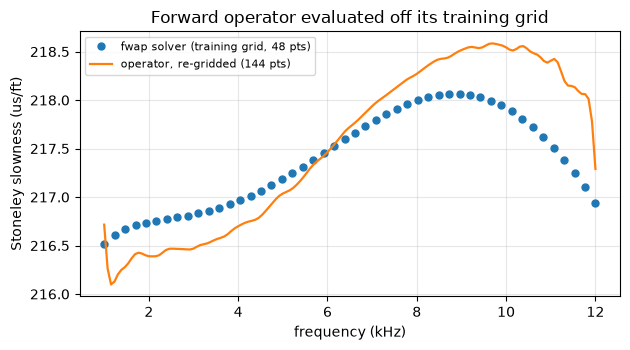

In [5]:
operator, history = train_cased_operator(bundle, split=split, epochs=60, seed=0)

mae = slowness_mae_us_per_ft(operator, bundle, split.test)
print(f"forward operator: final loss {history[-1]:.2e}   test MAE {mae:.3f} us/ft")

truth = bundle.slowness[np.isfinite(bundle.slowness)] * 0.3048e6
print(f"  (curve values span {truth.min():.0f}-{truth.max():.0f} us/ft)")

rel = resolution_transfer_error(operator, bundle, split.test, factor=3)
print(f"  zero-shot on a 3x finer grid: {rel:.3%} self-consistent at shared nodes")

features, _ = cased_features(bundle)
fine = np.linspace(operator.f_min, operator.f_max, 3 * bundle.n_freq)
pred_fine = operator.predict(features[split.test[:1]], freq=fine)[0, 0]

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(bundle.freq / 1e3, bundle.slowness[split.test[0], 0] * 0.3048e6,
        "o", ms=5, label=f"fwap solver (training grid, {bundle.n_freq} pts)")
ax.plot(fine / 1e3, pred_fine * 0.3048e6, "-", lw=1.6,
        label=f"operator, re-gridded ({fine.size} pts)")
ax.set_xlabel("frequency (kHz)")
ax.set_ylabel("Stoneley slowness (us/ft)")
ax.set_title("Forward operator evaluated off its training grid")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. The bond inverse

Now the direction that matters: **cased gather → (behind-casing Vs, bond
index)**. This reuses the open-hole tutorial's network unchanged — a 1-D CNN
over receivers with a heteroscedastic head predicting a mean *and* a variance per
target. Only the targets differ.

The gather is the sole input. The dispersion curve and the annulus properties
never enter, so the network has to do the inversion rather than read the answer.

In [6]:
net, nll_history = train_cased_inverse(bundle, split=split, epochs=80, seed=0)
print(f"inverse net: final train NLL {nll_history[-1]:.3f}")
print(f"targets: {net.active_names}")

for name in net.active_names:
    mae = cased_target_mae(net, bundle, split.test, name)
    truth = (bundle.bond_index if name == "bond_index" else bundle.param(name))
    naive = float(np.abs(truth[split.test] - truth[split.train].mean()).mean())
    unit = "" if name == "bond_index" else " m/s"
    print(f"  {name:<11} MAE {mae:8.3f}{unit}   predict-the-mean {naive:8.3f}{unit}"
          f"   skill {naive / mae:4.1f}x")

inverse net: final train NLL -0.074
targets: ('vs', 'bond_index')
  vs          MAE  231.776 m/s   predict-the-mean  339.559 m/s   skill  1.5x
  bond_index  MAE    0.111   predict-the-mean    0.240   skill  2.2x


## 5. Against a classical baseline

A fair comparison needs the right classical reference, and the obvious one is
*wrong* here. Field cement-bond logging keys off the **casing-ring amplitude** —
a free pipe rings, a bonded one does not. These synthetics are built from the
cased Stoneley dispersion alone and contain no casing-ring arrival at all, so a
CBL-amplitude indicator would be measuring noise, and beating it would prove
nothing.

`StoneleyBondBaseline` is the honest analogue: pick the Stoneley arrival with
slowness-time coherence, then map slowness to bond with a calibration fitted on
the training split. It uses the signal that is actually present, and it is given
the same training data the network saw.

In [7]:
# STC costs ~0.3 s per gather, so calibrate on a subset to keep this notebook brief.
classical = StoneleyBondBaseline().fit(bundle, geom, split.train[:50])
neural = NeuralBondPredictor(net)
mean_ref = MeanBondPredictor(float(bundle.bond_index[split.train].mean()))

cards = {
    p.name: evaluate_bond(p, bundle, geom, indices=split.test, seed=0, n_boot=400)
    for p in (mean_ref, classical, neural)
}
for card in cards.values():
    print(format_scorecard(card, row_order=BOND_ROW_ORDER, precision=3), "\n")

print("Bond-index median |error|, held-out test set:")
print(f"{'predictor':>20}  {'medAE':>8}  {'vs mean':>8}")
base = cards[mean_ref.name].per_regime["all"].median_abs_error
for name, card in cards.items():
    med = card.per_regime["all"].median_abs_error
    print(f"{name:>20}  {med:8.3f}  {base / med:7.1f}x")

Scorecard: mean_bond  (parameter: bond_index)
regime      n  finite     medAE    meanAE       95% CI (median)
---------------------------------------------------------------
   all     20      20     0.207     0.240        [0.113, 0.369]
  poor      6       6     0.285     0.306        [0.207, 0.427]
medium      9       9     0.097     0.097        [0.043, 0.144]
  good      5       5     0.390     0.417        [0.349, 0.502] 

Scorecard: stoneley_stc_bond  (parameter: bond_index)
regime      n  finite     medAE    meanAE       95% CI (median)
---------------------------------------------------------------
   all     20      20     0.215     0.233        [0.075, 0.327]
  poor      6       6     0.376     0.374        [0.243, 0.503]
medium      9       9     0.071     0.063        [0.018, 0.087]
  good      5       5     0.307     0.371        [0.265, 0.606] 

Scorecard: cased_inverse_net  (parameter: bond_index)
regime      n  finite     medAE    meanAE       95% CI (median)
----------

## 6. The uncertainty has to be honest

Section 2 predicted that bond is recoverable and behind-casing Vs is not. The
inverse net agrees — but a point estimate that is quietly wrong is worse than
useless on a cement job, so the question is whether the model's *own* error bars
say the same thing.

The check is the residual z-score: divide each error by the σ the model
predicted for it. If σ is honest, those standardized residuals have unit spread.
Much above 1 means the model is overconfident; much below means it is
needlessly vague.

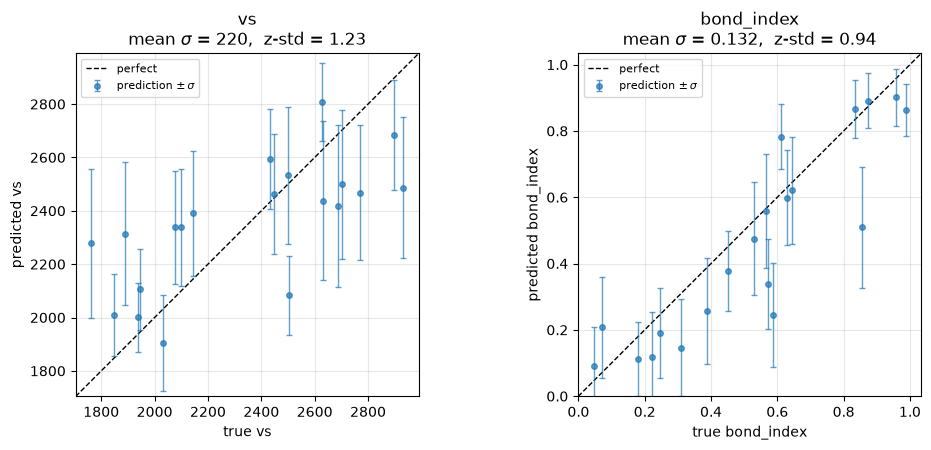

Residual z-score std (1.0 = calibrated):
  vs          1.23
  bond_index  0.94


In [8]:
params_pred, params_std = net.predict(bundle.gather[split.test])
truths = {"vs": bundle.param("vs"), "bond_index": bundle.bond_index}

fig, axes = plt.subplots(1, len(net.active_names), figsize=(5.2 * len(net.active_names), 4.6))
for ax, name in zip(np.atleast_1d(axes), net.active_names):
    col = net.active_names.index(name)
    true = truths[name][split.test]
    pred, sigma = params_pred[:, col], params_std[:, col]
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    pad = 0.05 * (lims[1] - lims[0])
    lims = [lims[0] - pad, lims[1] + pad]
    ax.plot(lims, lims, "k--", lw=1, label="perfect")
    ax.errorbar(true, pred, yerr=sigma, fmt="o", ms=4, alpha=0.7,
                elinewidth=1, capsize=2, label="prediction $\\pm\\,\\sigma$")
    z = cased_residual_zscore_std(net, bundle, split.test, name)
    ax.set_title(f"{name}\nmean $\\sigma$ = {sigma.mean():.3g},  z-std = {z:.2f}")
    ax.set_xlabel(f"true {name}")
    ax.set_ylabel(f"predicted {name}")
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Residual z-score std (1.0 = calibrated):")
for name in net.active_names:
    print(f"  {name:<11} {cased_residual_zscore_std(net, bundle, split.test, name):.2f}")

## What this shows

**The forward sensitivity sweep predicted the result, and the inverse confirmed
it.** Cement bond is the dominant control on the cased Stoneley curve and is
recoverable — the learned inverse roughly halves the error of predicting the
mean and beats the classical Stoneley calibration. Behind-casing formation Vs
moves the data less than the nuisance parameters do, and is correspondingly
weak.

**The error bars are the deliverable, not a decoration.** With z-scores near 1,
the model's σ is doing real work: it reports a wide interval on Vs precisely
where the physics says the data is uninformative. On a cement job, "0.4 ± 0.13"
is an actionable answer and a confident-looking "0.41" is a liability.

**This is not the open-hole result, and it should not be.** There the inverse
beat classical processing by ~25×; here the honest figure is closer to 2×. The
difference is not modelling effort — it is that one problem is well-posed from a
single-mode measurement and the other is only partially so. Reporting the
smaller number is the point.

### What this does *not* show

Everything here is synthetic, and the net is scored on data drawn from the same
forward model that trained it, so this measures identifiability rather than
field accuracy. More specifically:

* **This is not a free-pipe detector.** The dataset spans the bonded regime,
  where the cased Stoneley mode is bound. Fully debonded casing is a leaky,
  ring-dominated problem outside this training set entirely — and it is the
  regime where a CBL-amplitude baseline would finally be the right comparison.
* Real cased-hole records bring eccentering, micro-annulus, channelling and
  tool/collar effects that no part of this pipeline models.
* **The held-out split here is tiny** (20 samples, with the classical
  calibration fitted on 50) so the individual figures above are noisy — in this
  run the classical baseline lands level with predicting the mean, which
  flatters the comparison; on a larger run it sits modestly ahead of the mean
  and the learned inverse's margin over it narrows. The `CHANGELOG` quotes
  numbers from larger runs with their sample counts. Treat the *ordering and the
  sensitivity argument* as the result, not the third decimal place.

The honest summary: `sonic_ml` gives the cased-hole problem a fast forward
operator, a learned inverse, a fair baseline, and calibrated uncertainty — the
scaffolding an AlphaFold-style approach needs. What it does not give is a
field-ready cement-bond product, and the numbers above are reported so the gap
stays visible.